<a href="https://colab.research.google.com/github/almazyadn/DiamondPricePrediction/blob/main/Diamond_Price_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Diamonds Price Prediction

#### **Course:** IT 461 — Principles of Machine Learning  
#### **Section:** 72598  
#### **Group:** 7  

**Team Members:**  
- Najla AlMazyad — 444200948  
- Jood AlKhrashi — 444203007  
- Sara AlOqiel — 444203016  
- Nouf AlMansour — 444200525  

**Supervisor:** Dr. Luluah AlHussain  
**Semester:** 1st Semester, 2025/26


> This notebook documents our implementation of the **Diamond Price Prediction** project, including code, brief theoretical context, model interpretation, practical application and future work.


### Project Overview

**Task:** Predict diamond prices using machine learning regression models.  
**Input:** Physical (carat, x, y, z, depth, table) and categorical (cut, color, clarity) features.  
**Output:** Predicted price (USD).  
**Significance:** Helps estimate fair market value, improves pricing transparency, and demonstrates supervised learning methods.  


#### What we’ll show
1) clean + explore the data  
2) build baselines (linear/regularized)  
3) try ensembles (RF, GB)  
4) tune at least one model  
5) compare on original $ scale (MAE, RMSE, R²)




---

## 1. Description & Motivation

Diamond pricing varies widely based on attributes such as **carat**, **cut**, **color**, **clarity**, and geometric dimensions (**x, y, z**).  
Small changes in these factors can cause significant price differences, making valuation complex and subjective.

This project applies **supervised learning** to predict diamond prices using these features.  
By modeling the relationship between diamond characteristics and price, we aim to demonstrate how data-driven methods can improve pricing transparency and reliability.


### 1.1 Problem Statement


**Goal:** Develop a **supervised regression model** to accurately predict diamond **price** using its physical and categorical attributes.

**Key Challenges:**
* Modeling the **nonlinear** relationship between features and price (especially carat).
* Handling features on different **numeric scales**.
* Addressing the **class imbalance** in the highly-priced segment.

**Objective:** Compare multiple regression models (linear, ensemble, neural network) to select the most accurate and interpretable predictive approach.


### 1.2 Intended Task



We frame the problem as a **supervised regression** task.

- **Input features (X):** `carat`, `cut`, `color`, `clarity`, `depth`, `table`, `x`, `y`, `z`  
- **Target (y):** `price` (USD)

**Planned Workflow:**
1. Load and inspect the dataset  
2. Perform exploratory data analysis (EDA)  
3. Encode categorical variables (`cut`, `color`, `clarity`)  
4. Normalize numeric features using **StandardScaler (Z-score normalization)**  
5. Split data into training and testing sets  
6. Train and evaluate models:
   - Linear Regression (baseline)
   - Random Forest Regressor
   - Gradient Boosting Regressor
   - Neural Network (Different Architecture)
7. Compare model performance using **MAE**, **RMSE**, and **R²**  
8. Visualize and interpret feature importance
      

## 2. Background


Diamond valuation is a complex and often subjective process influenced by several physical and qualitative factors.  
The market price primarily depends on the **Four Cs**:

- **Carat:** The weight of the diamond  
- **Cut:** The quality of the diamond’s proportions and finish  
- **Color:** The absence or presence of color tint  
- **Clarity:** The number and visibility of internal or external flaws  

In addition to these characteristics, physical measurements such as **depth**, **table size**, and **dimensions (x, y, z)** also contribute to price variation.  
Even minor differences in these attributes can lead to significant price changes, making accurate price prediction a challenging task.

This project aims to build a **machine learning model** that predicts diamond prices based on these features, helping both consumers and professionals make more informed decisions.


### 2.1 Key Concepts



**Regression:** Predicts a continuous value (price) from input features.

**Feature Scaling:** We use **Z-score normalization (StandardScaler)** so all numeric features have mean 0 and std 1. This is crucial for **Linear Regression**; it does not harm tree models.

**Neural Networks:** We train a Multi-Layer Perceptron (MLP) model and test multiple architectures to capture nonlinear patterns and select the best-performing structure.

**Metrics:**  
- **MAE** — average absolute error  
- **RMSE** — penalizes larger errors  
- **R²** — proportion of variance explained




## 3. Importing Libraries



We begin by importing all required Python libraries for data analysis, preprocessing, visualization, and modeling.

This includes:
- **NumPy / Pandas** for data manipulation  
- **Matplotlib / Seaborn** for visualization  
- **Scikit-learn** for machine learning models and preprocessing  
- **XGBoost / LightGBM** for gradient boosting  
- **SHAP / ELI5** for model interpretability

In [ ]:
# Importing modules

import warnings
warnings.filterwarnings('ignore')
import time
t = time.time()

# Basic modules
import os
import numpy as np
import pandas as pd
import re
from scipy import stats
from random import randint

# Visualization modules
import matplotlib.pyplot as plt
import matplotlib
import seaborn as sns
import missingno as msno

# Preprocessing and model selection
from sklearn.model_selection import (train_test_split,
                                     KFold,
                                     StratifiedKFold,
                                     cross_val_score)

from sklearn.neural_network import MLPRegressor


from sklearn.preprocessing import (LabelEncoder,
                                   StandardScaler,
                                   MinMaxScaler,
                                   OrdinalEncoder,
                                   RobustScaler)

from sklearn.feature_selection import SelectFromModel
# Metrics
from sklearn.metrics import (mean_squared_error,
                             r2_score,
                             mean_absolute_error)

# Modeling algorithms
from sklearn.linear_model import (LogisticRegression,
                                  Lasso,
                                  ridge_regression,
                                  LinearRegression)
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import (AdaBoostRegressor,
                              RandomForestRegressor,
                              VotingRegressor,
                              GradientBoostingRegressor)
from xgboost import XGBRegressor
from lightgbm import (LGBMRegressor,
                      early_stopping)


# Pipeline utility
from sklearn.base import clone
from sklearn.pipeline import make_pipeline


## 4. Dataset Description



**Source:** The **`diamonds`** dataset from [**ggplot2 (tidyverse)**](https://ggplot2.tidyverse.org/), exported to CSV (≈53,940 rows). It contains prices and attributes of round-cut diamonds, including the Four Cs and physical measurements.  

**Features Overview**

| Type        | Features                         | Description                              |
|-------------|----------------------------------|------------------------------------------|
| Numerical   | carat, depth, table, x, y, z     | Physical measures and dimensions         |
| Categorical | cut, color, clarity              | Qualitative/ordinal characteristics      |
| Target      | price                             | Diamond price in USD                     |


**Why this dataset?** It is well-documented, sizable, and widely used for regression benchmarking, enabling clear comparisons of preprocessing and models.

**Goal:** Predict the `price` of a diamond using its physical and categorical characteristics.



### Dataset

In [ ]:
df = pd.read_csv("diamonds.csv")
df.head()

,Unnamed: 0,carat,cut,color,clarity,depth,table,price,x,y,z
0,1,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,2,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,3,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,4,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,5,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75


In [ ]:
print("Dataset shape:", df.shape)
print("Column names:", df.columns.tolist())

Dataset shape: (53940, 11)
Column names: ['Unnamed: 0', 'carat', 'cut', 'color', 'clarity', 'depth', 'table', 'price', 'x', 'y', 'z']


### Dataset Summary

- **Source:** ggplot2 “diamonds” dataset (53,940 samples × 10 features)  
- **Target variable:** `price` (continuous numeric value in USD)  
- **Numerical features:** `carat`, `depth`, `table`, `x`, `y`, `z`  
- **Categorical features:** `cut`, `color`, `clarity`  
- **Purpose:** Predict `price` based on both physical and categorical characteristics.  


## 5. Exploratory Data Analysis (EDA) and Statistics



To understand the dataset, we explore statistical summaries, check for missing values, and visualize how diamond characteristics affect price.

We will:
- Review descriptive statistics  
- Plot price distribution  
- Compare price by cut, color, and clarity  
- Visualize correlations and numerical relationships


### Summary Statistics

In [ ]:
df.describe()


,Unnamed: 0,carat,depth,table,price,x,y,z
count,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000
mean,26970.500000,0.797940,61.749405,57.457184,3932.799722,5.731157,5.734526,3.538734
std,15571.281097,0.474011,1.432621,2.234491,3989.439738,1.121761,1.142135,0.705699
min,1.000000,0.200000,43.000000,43.000000,326.000000,0.000000,0.000000,0.000000
25%,13485.750000,0.400000,61.000000,56.000000,950.000000,4.710000,4.720000,2.910000
50%,26970.500000,0.700000,61.800000,57.000000,2401.000000,5.700000,5.710000,3.530000
75%,40455.250000,1.040000,62.500000,59.000000,5324.250000,6.540000,6.540000,4.040000
max,53940.000000,5.010000,79.000000,95.000000,18823.000000,10.740000,58.900000,31.800000


### EDA Helper Functions

In [ ]:
# --- EDA helpers ---
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

def plot_hist(df, col, bins=30, title=None, xlabel=None, ylabel="Frequency"):
    plt.figure(figsize=(6,4))
    plt.hist(df[col], bins=bins, edgecolor='black')
    plt.title(title or f"{col} Distribution")
    plt.xlabel(xlabel or col)
    plt.ylabel(ylabel)
    plt.tight_layout()
    plt.show()

def plot_hist_by_category(df, col, by, bins=30, title=None):
    # separate hist per category (small multiples)
    cats = df[by].unique()
    n = len(cats)
    cols = min(3, n)
    rows = int(np.ceil(n / cols))
    plt.figure(figsize=(5*cols, 3.8*rows))
    for i, c in enumerate(cats, 1):
        plt.subplot(rows, cols, i)
        subset = df[df[by] == c]
        plt.hist(subset[col], bins=bins, edgecolor='black')
        plt.title(f"{col} | {by} = {c}")
        plt.xlabel(col)
        plt.ylabel("Freq")
    plt.suptitle(title or f"{col} by {by}", y=1.02)
    plt.tight_layout()
    plt.show()

def plot_scatter(df, x, y, hue=None, alpha=0.5, title=None, xlabel=None, ylabel=None):
    plt.figure(figsize=(6,4))
    if hue:
        sns.scatterplot(data=df, x=x, y=y, hue=hue, alpha=alpha)
    else:
        sns.scatterplot(data=df, x=x, y=y, alpha=alpha)
    plt.title(title or f"{y} vs {x}")
    plt.xlabel(xlabel or x)
    plt.ylabel(ylabel or y)
    plt.tight_layout()
    plt.show()

def plot_scatter_grid(df, x_list, y, alpha=0.5, title_prefix=None):
    # grid of scatterplots: each x in x_list against y
    n = len(x_list)
    cols = min(3, n)
    rows = int(np.ceil(n / cols))
    plt.figure(figsize=(5*cols, 3.8*rows))
    for i, x in enumerate(x_list, 1):
        plt.subplot(rows, cols, i)
        sns.scatterplot(data=df, x=x, y=y, alpha=alpha)
        plt.title(f"{title_prefix or y} vs {x}")
        plt.xlabel(x)
        plt.ylabel(y)
    plt.tight_layout()
    plt.show()

def plot_bar_avg(df, cat, y, order=None, title=None, xlabel=None, ylabel=None):
    # bar of mean(y) by cat
    means = df.groupby(cat)[y].mean().reset_index()
    if order:
        means[cat] = pd.Categorical(means[cat], categories=order, ordered=True)
        means = means.sort_values(cat)
    plt.figure(figsize=(6,4))
    sns.barplot(data=means, x=cat, y=y)
    plt.title(title or f"Average {y} by {cat}")
    plt.xlabel(xlabel or cat)
    plt.ylabel(ylabel or f"Average {y}")
    plt.tight_layout()
    plt.show()

def plot_bar_avg_2cat(df, cat1, cat2, y, title=None):
    # pivot heatmap of mean(y) for 2 categorical variables
    pivot = df.pivot_table(index=cat1, columns=cat2, values=y, aggfunc='mean')
    plt.figure(figsize=(6,4))
    sns.heatmap(pivot, annot=True, fmt=".0f", cmap="Blues")
    plt.title(title or f"Avg {y} by {cat1} × {cat2}")
    plt.tight_layout()
    plt.show()

def plot_count(df, cat, title=None, xlabel=None, ylabel="Count"):
    plt.figure(figsize=(6,4))
    sns.countplot(data=df, x=cat)
    plt.title(title or f"{cat} Counts")
    plt.xlabel(xlabel or cat)
    plt.ylabel(ylabel)
    plt.tight_layout()
    plt.show()

def plot_box(df, cat, y, order=None, title=None):
    plt.figure(figsize=(6,4))
    if order:
        df = df.copy()
        df[cat] = pd.Categorical(df[cat], categories=order, ordered=True)
    sns.boxplot(data=df, x=cat, y=y)
    plt.title(title or f"{y} by {cat} (Boxplot)")
    plt.tight_layout()
    plt.show()

def plot_violin(df, cat, y, order=None, title=None):
    plt.figure(figsize=(6,4))
    if order:
        df = df.copy()
        df[cat] = pd.Categorical(df[cat], categories=order, ordered=True)
    sns.violinplot(data=df, x=cat, y=y, inner='quartile')
    plt.title(title or f"{y} by {cat} (Violin)")
    plt.tight_layout()
    plt.show()

def plot_corr_heatmap(df, title="Correlation Heatmap (Numeric Features)"):
    plt.figure(figsize=(7,6))
    corr = df.corr(numeric_only=True)
    sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
    plt.title(title)
    plt.tight_layout()
    plt.show()


### Missing Values Check



No missing values were detected in any column, confirming that the dataset is complete and does not require imputation.


In [ ]:
df = df.drop(columns=["Unnamed: 0"])
df.isnull().sum()

,0
carat,0
cut,0
color,0
clarity,0
depth,0
table,0
price,0
x,0
y,0
z,0


### Price Distribution Summary

The **price** feature is highly skewed:

- 50% of diamonds are priced below **\$2,401**
- 75% are priced below **\$5,324**
- with a maximum value reaching **\$18,823**

This suggests a **right-skewed distribution**, which will be confirmed using a histogram in the next visualization.


In [ ]:
df['price'].describe()


,price
count,53940.000000
mean,3932.799722
std,3989.439738
min,326.000000
25%,950.000000
50%,2401.000000
75%,5324.250000
max,18823.000000


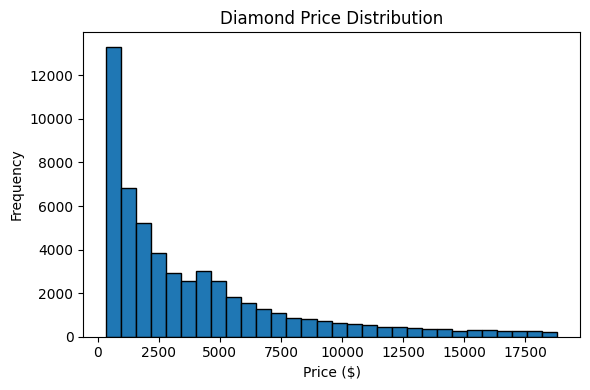

In [ ]:
plot_hist(df, 'price', bins=30, title="Diamond Price Distribution", xlabel="Price ($)")

The histogram confirms that diamond prices are **right-skewed**, with most diamonds concentrated at the lower end of the price range.  
Only a small proportion of diamonds exceed **\$10,000**, suggesting the presence of potential **outliers**.  
This skewness indicates that applying a **logarithmic transformation** later could help stabilize variance and improve regression model performance.

### Correlation Heatmap Analysis

The heatmap highlights the relationships among numerical features and **price**:

- **Carat** has the **strongest positive correlation** with price, confirming that larger diamonds are generally more expensive.  
- Dimensions **x**, **y**, and **z** also show strong positive correlations with price and with each other, as they collectively represent diamond size.  
- **Depth** and **table** exhibit **weak or slightly negative correlations** with price, indicating that cut proportions have less direct impact on pricing.  
- The strong intercorrelation among carat, x, y, and z suggests potential **multicollinearity** (when two or more predictor variables are highly correlated, making it harder for the model to distinguish their individual effects), which may need attention during model training.

Overall, this analysis supports that **carat** and **physical dimensions** are the most influential numerical predictors of diamond price.

**Takeaway:** **Carat** and dimensions (**x, y, z**) have the **strongest correlations** with price, while **depth** and **table** are weak. Their high intercorrelation indicates **multicollinearity**, so applying **regularization or feature selection** can help stabilize linear models.


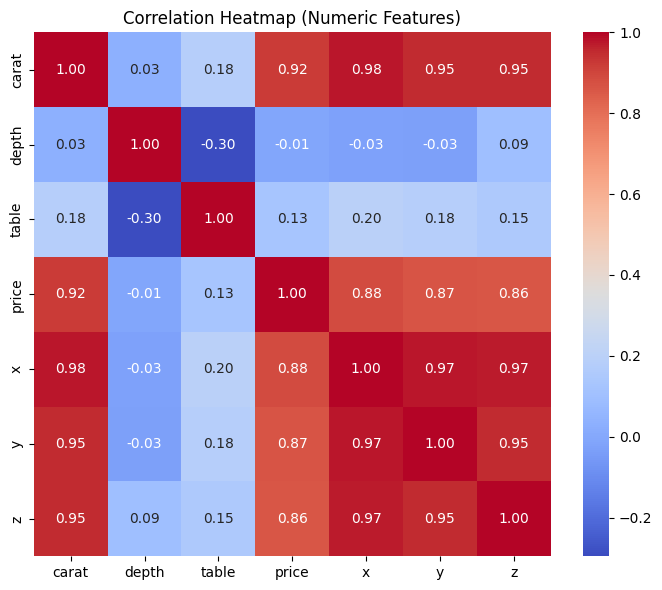

In [ ]:
plot_corr_heatmap(df)

### Average Price by Categorical Features

- **Average Price by Cut**

The table shows the **average price** for each cut category.  
Diamonds with a **Premium cut** have the highest mean price, but interestingly, the **Fair** cut also ranks relatively high — higher than *Ideal* and *Very Good* cuts.  
This unexpected result may be due to **Fair-cut diamonds typically having larger carat sizes**, which raises their total price even if their cut quality is lower.  
Overall, while **cut** influences price, its effect is less dominant than **carat weight** or **clarity**.
[link text](https://)

In [ ]:
df.groupby('cut')['price'].mean().sort_values(ascending=False)


,price
cut,
Premium,4584.257704
Fair,4358.757764
Very Good,3981.759891
Good,3928.864452
Ideal,3457.541970


The plot shows a moderate increase in average price with better cut quality.  
Diamonds graded **Premium** and **Fair** have slightly higher average prices, while **Ideal** and **Very Good** cuts are moderately priced.  
This indicates that **cut** affects price but not as strongly as other features like carat or clarity.

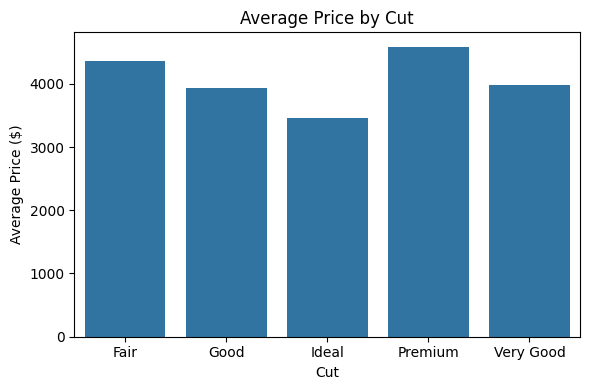

In [ ]:
plot_bar_avg(
    df,
    cat='cut',
    y='price',
    title="Average Price by Cut",
    xlabel="Cut",
    ylabel="Average Price ($)"
)

- **Average Price by Color**

The table lists the **average price by color grade**.  
Diamonds with lower color grades (**J**, **I**) have higher average prices, while colorless diamonds (**D**, **E**) are less expensive on average.  
This pattern suggests that **color alone does not dictate price**, as higher-priced diamonds in lower color grades may also be larger in carat size.


In [ ]:
df.groupby('color')['price'].mean().sort_values(ascending=False)


,price
color,
J,5323.818020
I,5091.874954
H,4486.669196
G,3999.135671
F,3724.886397
D,3169.954096
E,3076.752475


The chart reveals an inverse relationship between **color quality** and **price**.  
Diamonds with lower color grades (J, I, H) — which have a yellowish tint — tend to be **more expensive**, likely because they are larger in size.  
Conversely, colorless diamonds (grades D–E) show slightly lower average prices, possibly due to smaller average carat weights within those groups.  
This indicates that color alone does not determine price and interacts with other attributes like carat.

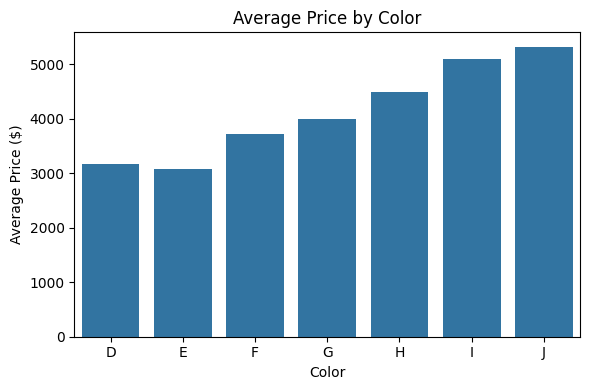

In [ ]:
plot_bar_avg(
    df,
    cat='color',
    y='price',
    title="Average Price by Color",
    xlabel="Color",
    ylabel="Average Price ($)"
)

- **Average Price by Clarity**

The table summarizes the **average price across clarity grades**.  
Interestingly, diamonds with **more inclusions (SI2, SI1)** show higher average prices compared to flawless diamonds (**IF**, **VVS1**).  
This indicates that **carat weight** may be influencing the trend — larger diamonds often have lower clarity but still higher overall prices.


In [ ]:
df.groupby('clarity')['price'].mean().sort_values(ascending=False)


,price
clarity,
SI2,5063.028606
SI1,3996.001148
VS2,3924.989395
I1,3924.168691
VS1,3839.455391
VVS2,3283.737071
IF,2864.839106
VVS1,2523.114637


Chart shows that diamonds with lower clarity grades such as **SI2** and **SI1** have the **highest average prices**, while flawless or near-flawless diamonds (**VVS1**, **IF**) are relatively lower on average.  
This unexpected pattern likely arises because larger diamonds tend to have more inclusions, increasing both their weight and total price.  
Therefore, **clarity** influences value, but its effect is intertwined with **carat size**.


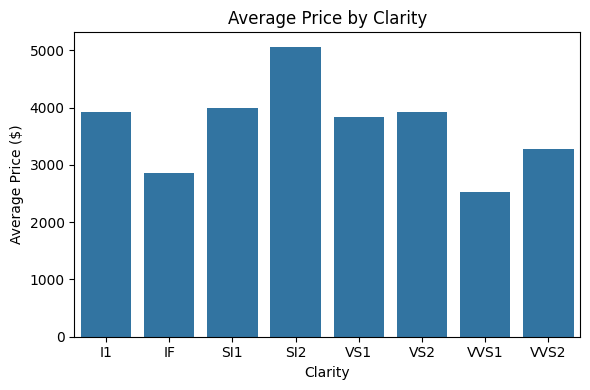

In [ ]:
plot_bar_avg(
    df,
    cat='clarity',
    y='price',
    title="Average Price by Clarity",
    xlabel="Clarity",
    ylabel="Average Price ($)"
)



Across the bar charts for **cut, color, and clarity**, we observed an **unexpected inverse relationship** (e.g., lower grades often show a higher *average* price). This pattern suggests that **carat size strongly mediates** the effect of the Four Cs—lower-quality diamonds in this dataset often have a **larger average carat weight**, which overrides quality effects and drives the total price up regardless of quality. This confirms the necessity of including **carat and dimensional features** in our regression to properly disentangle these complex interactions.

### Combined Effect of Cut, Color, and Clarity

This chart shows the **average price for every (cut, color, clarity)** combination.

**Observation:** Combinations with consistently high quality (e.g., *Very Good–D–IF*, *Premium–E–VVS1*) appear at the top, while lower quality mixes cluster at the bottom.

**Takeaway:** Price depends on **interactions** among categorical features—not only their individual effects—which supports using **one-hot encoding** so models can learn these joint patterns.


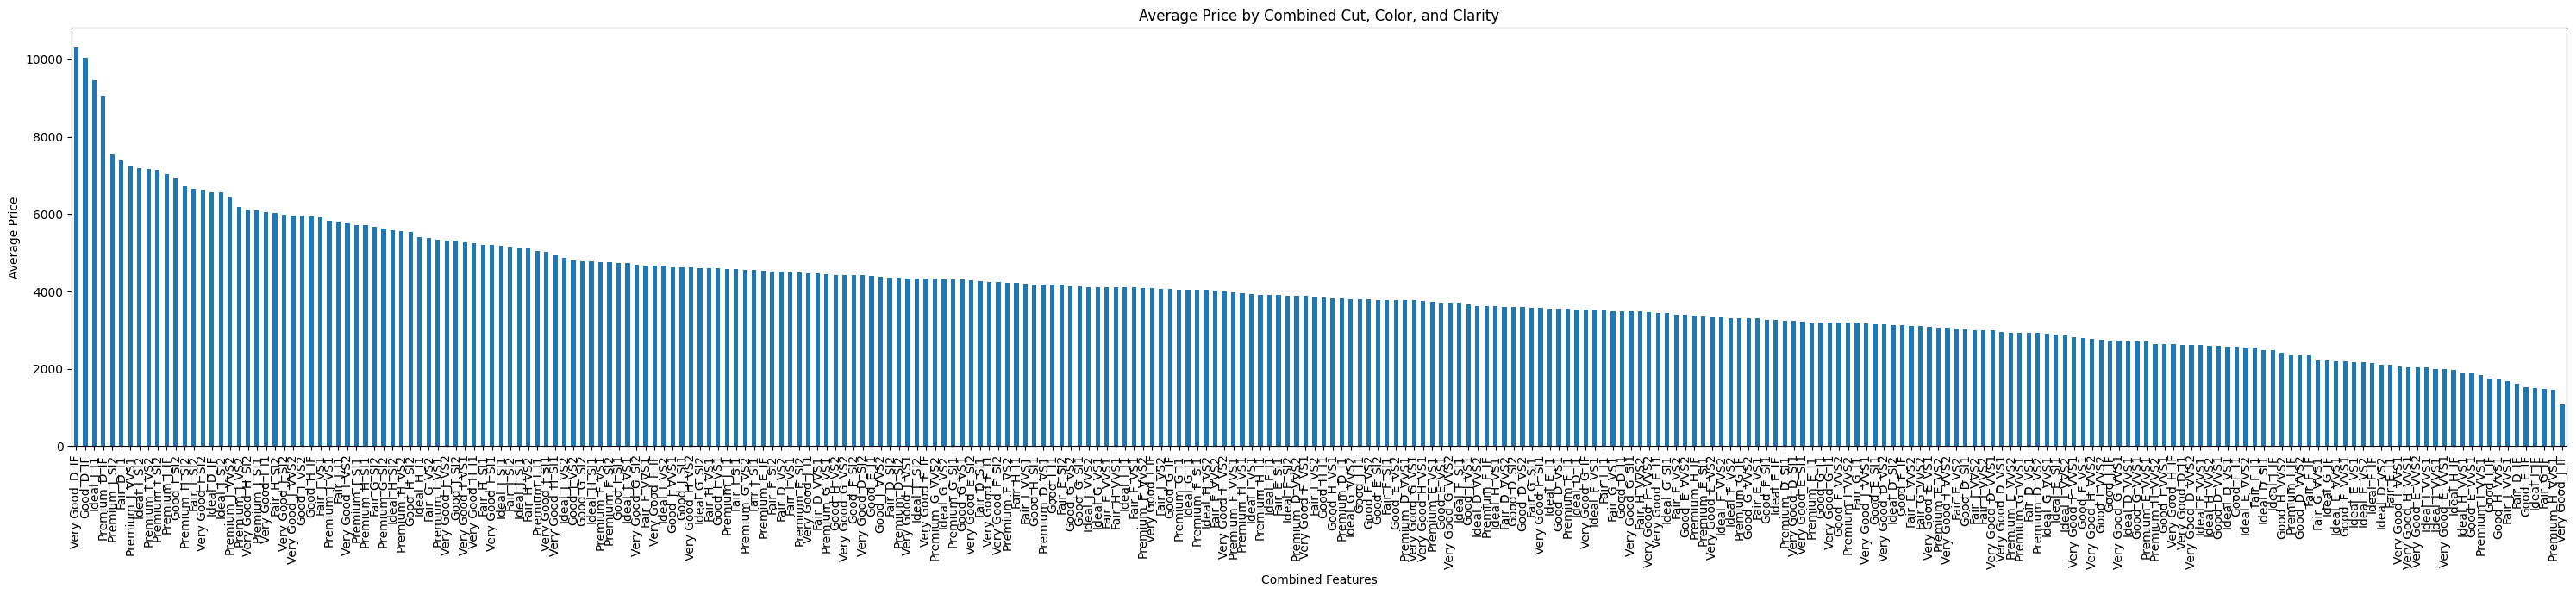

In [ ]:
def plot_bar_avg_combined(df, features, target='price', title=None):
    """Plot average target by a combination of categorical features."""
    combined = df[features].astype(str).agg('_'.join, axis=1)
    avg = df.groupby(combined)[target].mean().sort_values(ascending=False)
    plt.figure(figsize=(30, 7))
    avg.plot(kind='bar')
    plt.title(title or f"Average {target} by Combined {'_'.join(features)}")
    plt.xlabel("Combined Features")
    plt.ylabel(f"Average {target.capitalize()}")
    plt.xticks(rotation=90)
    plt.tight_layout()
    plt.show()

# usage
plot_bar_avg_combined(
    df,
    features=['cut', 'color', 'clarity'],
    target='price',
    title="Average Price by Combined Cut, Color, and Clarity"
)


### Relationship Between Dimensions and Price

Before visualizing how diamond dimensions relate to price, we first inspect their summary statistics to identify potential irregularities or outliers.


In [ ]:
df[['carat', 'depth', 'table', 'x', 'y', 'z']].describe()


,carat,depth,table,x,y,z
count,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000
mean,0.797940,61.749405,57.457184,5.731157,5.734526,3.538734
std,0.474011,1.432621,2.234491,1.121761,1.142135,0.705699
min,0.200000,43.000000,43.000000,0.000000,0.000000,0.000000
25%,0.400000,61.000000,56.000000,4.710000,4.720000,2.910000
50%,0.700000,61.800000,57.000000,5.700000,5.710000,3.530000
75%,1.040000,62.500000,59.000000,6.540000,6.540000,4.040000
max,5.010000,79.000000,95.000000,10.740000,58.900000,31.800000


From the table above:

- **Carat** ranges from *0.2 to 5.01*, indicating large variation in diamond sizes.  
- **Depth** and **table** have reasonable spreads, with standard deviations of about **1.43** and **2.23**, suggesting most diamonds fall within a narrow shape proportion range.  
- **x, y, z** dimensions (length, width, depth in mm) show **minimum values of 0**, which are physically unrealistic and likely represent **data entry errors or missing values** that should be handled during preprocessing.  

**Takeaway:** Dimensional attributes are generally consistent, but **invalid zero entries in x, y, and z** must be cleaned before modeling.


- **Price vs. Carat**

The scatter plot shows a **strong positive relationship** between **carat** and **price** — larger diamonds tend to be significantly more expensive.  
However, the spread widens as carat increases, indicating **nonlinear growth** (price rises faster than carat).  
This supports the need for **log-transformation** to better capture this nonlinear pattern in modeling.


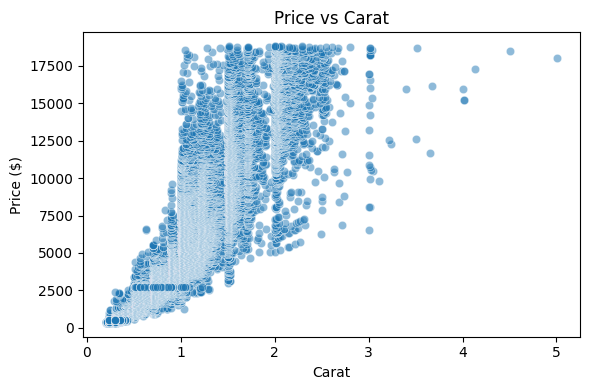

In [ ]:
plot_scatter(df, x='carat', y='price', alpha=0.5, title="Price vs Carat", xlabel="Carat", ylabel="Price ($)")

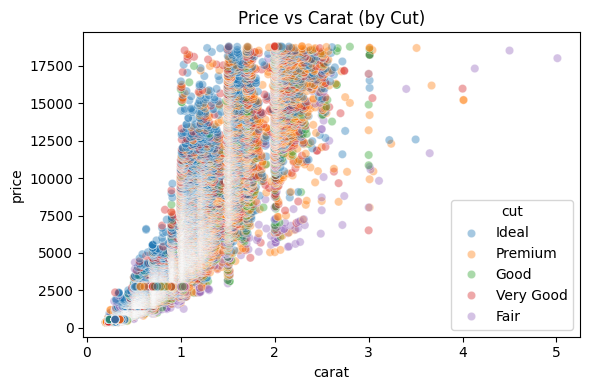

In [ ]:
plot_scatter(df, x='carat', y='price', hue='cut', alpha=0.4, title="Price vs Carat (by Cut)")


- **Price vs. x (Length)**

Diamonds with greater **length (x)** generally show higher prices, reinforcing the trend that **larger physical dimensions** correlate with value.  
However, some points near **x = 0** indicate **invalid entries**, as a diamond cannot have zero length. These anomalies confirm the need for **data cleaning** before modeling.

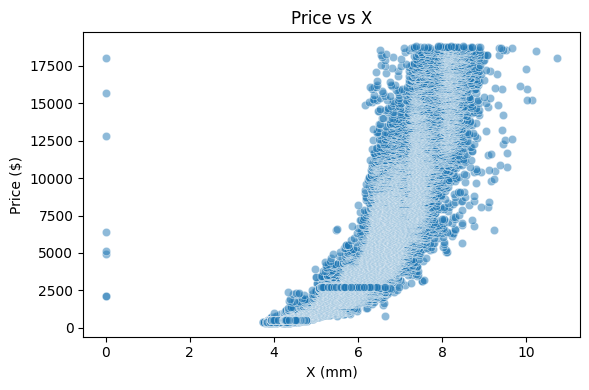

In [ ]:
plot_scatter(
    df,
    x='x',
    y='price',
    alpha=0.5,
    title="Price vs X",
    xlabel="X (mm)",
    ylabel="Price ($)"
)


- **Price vs. y (Width)**

The **Y (width)** dimension shows a similar pattern to **X (length)** — higher values generally correspond to higher prices.  
However, several extreme outliers (e.g., values around **30–60 mm**) are unrealistic for diamond width, confirming the presence of **erroneous data points** that must be corrected or removed.


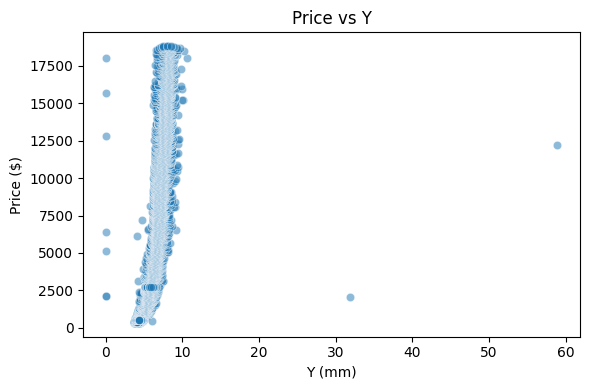

In [ ]:
plot_scatter(df, x='y', y='price', alpha=0.5, title="Price vs Y", xlabel="Y (mm)", ylabel="Price ($)")


- **Price vs. z (Depth)**

The **Y (width)** dimension shows a similar pattern to **X (length)** — higher values generally correspond to higher prices.  
However, several extreme outliers (e.g., values between **30–60 mm**) are **physically unrealistic**, since typical diamond dimensions range from **3 to 10 mm** even for large stones.  
Such values suggest **measurement or data entry errors**, which need to be corrected or removed before modeling.



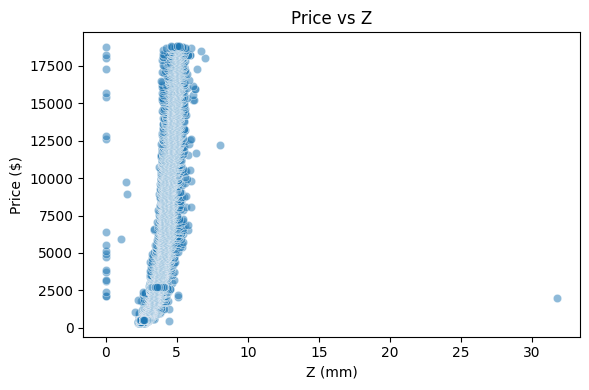

In [ ]:
plot_scatter( df, x='z', y='price', alpha=0.5, title="Price vs Z", xlabel="Z (mm)", ylabel="Price ($)" )


**Takeaway:**  
Across all three dimensions (**X, Y, Z**) and **carat**, larger diamonds generally correspond to higher prices.  
However, extreme and zero values in these numerical attributes indicate **measurement or recording errors**, highlighting the need for **data preprocessing** to ensure model reliability.


## 6.  Data Preprocessing

### 6.1 Data Cleaning



Before analysis, rows with **physically impossible diamond dimensions** (where any of `x`, `y`, or `z` ≤ 0) are removed.  
This step ensures data quality and prevents skewed correlations or invalid model training.

In [ ]:
def clean_diamonds(df):
    """Remove physically impossible entries and reset index."""
    invalid = (df[['x', 'y', 'z']] <= 0).any(axis=1)
    print(f"Removed {invalid.sum()} invalid rows with non-positive dimensions.")
    return df.loc[~invalid].reset_index(drop=True)

df = clean_diamonds(df)

Removed 20 invalid rows with non-positive dimensions.


Example of cleaned dataset:

In [ ]:
df.sample(5, random_state=42)

,carat,cut,color,clarity,depth,table,price,x,y,z
34687,0.31,Premium,F,IF,60.8,59.0,874,4.36,4.39,2.66
21090,1.29,Ideal,H,VS1,61.8,56.0,9273,6.97,7.02,4.32
23676,1.52,Premium,F,SI1,62.6,59.0,11743,7.36,7.27,4.58
39183,0.41,Good,F,VVS2,63.6,56.0,1064,4.72,4.68,2.99
35543,0.35,Premium,G,VS1,61.5,58.0,906,4.54,4.50,2.78


### 6.2 Data Encoding

To ensure our dataset is ready for modeling, we must first preprocess categorical attributes. In this step, we will encode:

- Cut

- Color

- Clarity

These categorical variables are non-numeric, so we apply One-Hot Encoding to transform them into numerical binary indicators. This allows machine learning models to interpret and use these features effectively while preserving category distinctions.

In [ ]:
df_encoded = pd.get_dummies(df, columns=['cut', 'color', 'clarity'], drop_first=True)
df_encoded.head()

,carat,depth,table,price,x,y,z,cut_Good,cut_Ideal,cut_Premium,...,color_H,color_I,color_J,clarity_IF,clarity_SI1,clarity_SI2,clarity_VS1,clarity_VS2,clarity_VVS1,clarity_VVS2
0,0.23,61.5,55.0,326,3.95,3.98,2.43,False,True,False,...,False,False,False,False,False,True,False,False,False,False
1,0.21,59.8,61.0,326,3.89,3.84,2.31,False,False,True,...,False,False,False,False,True,False,False,False,False,False
2,0.23,56.9,65.0,327,4.05,4.07,2.31,True,False,False,...,False,False,False,False,False,False,True,False,False,False
3,0.29,62.4,58.0,334,4.20,4.23,2.63,False,False,True,...,False,True,False,False,False,False,False,True,False,False
4,0.31,63.3,58.0,335,4.34,4.35,2.75,True,False,False,...,False,False,True,False,False,True,False,False,False,False


### 6.3 Outliers Removal

In [ ]:
Q1 = df['price'].quantile(0.25)
Q3 = df['price'].quantile(0.75)
IQR = Q3 - Q1

# Define bounds
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Filter out outliers
df_no_outliers = df[(df['price'] >= lower_bound) & (df['price'] <= upper_bound)]

print(f"Original rows: {len(df)}")
print(f"After removing outliers: {len(df_no_outliers)}")

Original rows: 53920
After removing outliers: 50388


Before analyzing the relationship between **cut**, **color**, and **clarity** with the diamond **price**, we removed extreme outliers to ensure the results better reflect general trends rather than being skewed by rare or unusually priced entries.

We used the **Interquartile Range (IQR)** method to detect and remove outliers:

- **Q1**: 25th percentile of price  
- **Q3**: 75th percentile of price  
- **IQR** = Q3 - Q1  
- Values below **Q1 - 1.5 × IQR** or above **Q3 + 1.5 × IQR** were considered outliers and removed.

This approach helps preserve the majority of the dataset while filtering out extremely rare diamonds with abnormally high or low prices. The cleaned dataset provides a more accurate representation of how typical cut, color, and clarity combinations affect average pricing.

### 6.4 Data Augmentation

To address the imbalance between low-priced and high-priced diamonds, we applied targeted augmentation:
- The dataset contains far fewer high-price diamonds, which can bias the model.

- We identified diamonds in the top 20 percent of the price range.

- We generated synthetic high-price samples by adding small noise to numerical features.

- This increased the representation of expensive diamonds and helped the model learn price patterns more accurately.

In [ ]:

NUMERIC_FEATURES = ['carat', 'depth', 'table', 'x', 'y', 'z']
N_COPIES_TO_MAKE = 3
MAX_NOISE_FACTOR = 0.04 # +/- 4%

def augment_data_by_perturbation(data_to_augment, n_copies, max_noise_factor, P_THRESHOLD):
    """Generates synthetic data points by adding random noise to numerical features."""
    synthetic_data = []

    for _ in range(n_copies):
        df_copy = data_to_augment.copy()

        # 1. Perturb Features (X)
        for col in NUMERIC_FEATURES:
            # Generate multiplicative noise
            noise = np.random.uniform(
                low=1 - max_noise_factor,
                high=1 + max_noise_factor,
                size=len(df_copy)
            )
            df_copy[col] = df_copy[col] * noise

        # 2. Ensure Label (y) meets the threshold
        df_copy['price'] = np.maximum(df_copy['price'], P_THRESHOLD)

        synthetic_data.append(df_copy)
    return pd.concat(synthetic_data, ignore_index=True)


# 1. Calculate the 80th percentile (Top 20%)
P_THRESHOLD = df['price'].quantile(0.80)
df_minority = df[df['price'] >= P_THRESHOLD].copy()

# 2. Generate the synthetic data
df_synthetic = augment_data_by_perturbation(
    df_minority,
    N_COPIES_TO_MAKE,
    MAX_NOISE_FACTOR,
    P_THRESHOLD
)

# 3. Combine and Overwrite the original 'df'
df = pd.concat([df_encoded, df_synthetic], ignore_index=True)

# 4. Shuffle the final augmented dataset
df = df.sample(frac=1).reset_index(drop=True)


# Verification:
print(f"Price Threshold (Top 20%): ${P_THRESHOLD:,.2f}")
print(f"Original Cleaned Rows: {len(df) - len(df_synthetic)}")
print(f"Synthetic Rows Added: {len(df_synthetic)}")
print(f"New Total Rows (Augmented): {len(df)}")


#saving the Preprocessed dataset
df.to_csv('Preprocessedـdatasets.csv', index=False)

Price Threshold (Top 20%): $6,300.00
Original Cleaned Rows: 53920
Synthetic Rows Added: 32376
New Total Rows (Augmented): 86296


### 6.5 Feature Scaling

After encoding categorical variables, we standardize the numerical features and target variable to ensure they are on a consistent scale.  
Machine learning algorithms can be sensitive to the magnitude of features — for example, `carat` may range in whole numbers while `depth` and `table` are percentages.  
To prevent larger-valued features from dominating model training, we apply **Standardization** using `StandardScaler` from scikit-learn.  

This transformation ensures that each scaled variable has:  
- **Mean = 0**  
- **Standard Deviation = 1**

In this step:
- The dataset is first split into training and testing sets, and the training portion is further split into a training and validation set to support model tuning and prevent data leakage.
- Only the **continuous numeric features** are scaled:  
  - `carat`  
  - `depth`  
  - `table`  
  - `x`  
  - `y`  
  - `z`  
- Categorical (one-hot encoded) columns remain binary (0/1) and are not scaled.  
- The **target variable (`price`)** is scaled separately using another `StandardScaler`, allowing it to be inverse-transformed later for evaluation in real dollar values.

This normalization process improves **model stability**, ensures **faster convergence**, and helps all algorithms treat features **equitably** during training.


In [ ]:

# Separate features & target
X_full = df_encoded.drop(columns=["price"]).copy()
y_full = df_encoded["price"].values.reshape(-1, 1)

# 1) First split: Train + Test
X_train_raw, X_test_raw, y_train_raw, y_test_raw = train_test_split(
    X_full, y_full, test_size=0.2, random_state=42
)

# 2) Second split: Train + Validation (from the training part only)
X_train_raw, X_val_raw, y_train_raw, y_val_raw = train_test_split(
    X_train_raw, y_train_raw, test_size=0.2, random_state=42
)

print("Train shape     :", X_train_raw.shape)
print("Validation shape:", X_val_raw.shape)
print("Test shape      :", X_test_raw.shape)

# 3) Scale continuous numeric columns only
numeric_features = ['carat', 'depth', 'table', 'x', 'y', 'z']

scaler_X = StandardScaler()

X_train_scaled = X_train_raw.copy()
X_val_scaled   = X_val_raw.copy()
X_test_scaled  = X_test_raw.copy()

X_train_scaled[numeric_features] = scaler_X.fit_transform(X_train_raw[numeric_features])
X_val_scaled[numeric_features]   = scaler_X.transform(X_val_raw[numeric_features])
X_test_scaled[numeric_features]  = scaler_X.transform(X_test_raw[numeric_features])

# 4) Scale target variable (price)
scaler_y = StandardScaler()

y_train_scaled = scaler_y.fit_transform(y_train_raw)
y_val_scaled   = scaler_y.transform(y_val_raw)
y_test_scaled  = scaler_y.transform(y_test_raw)


Train shape     : (34508, 23)
Validation shape: (8628, 23)
Test shape      : (10784, 23)


We standardized numeric features (mean = 0, std = 1) to balance feature influence.  
Categorical dummy columns remain binary.  
Target `price` is scaled separately to avoid data leakage.


## 7. Model Training

With the dataset fully preprocessed and ready, we now proceed to train predictive models on the encoded and normalized features. The training phase involves:

- Splitting the dataset into training and testing sets

- Selecting appropriate machine learning algorithms

- Fitting the models on the training data

- Evaluating performance on unseen data

This step allows us to assess how well each model learns the relationship between diamond features and price, and ultimately determine the most effective predictive approach.

### Modeling Helper Functions

In [ ]:
def evaluate_model_scaled(model, X_test, y_test, scaler_y, model_name):
    y_pred_scaled = model.predict(X_test)
    y_pred = scaler_y.inverse_transform(y_pred_scaled.reshape(-1, 1)).ravel()
    y_true = scaler_y.inverse_transform(y_test.reshape(-1, 1)).ravel()

    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)

    print(f"{model_name}")
    print(f"MAE : ${mae:,.2f}")
    print(f"RMSE: ${rmse:,.2f}")
    print(f"R²  : {r2:.4f}\n")
    return mae, rmse, r2



def plot_predicted_vs_actual(y_true, y_pred, model_name="Model"):
    plt.figure(figsize=(7,6))
    plt.scatter(y_true, y_pred, alpha=0.4, color='teal', edgecolor='white')
    plt.plot([y_true.min(), y_true.max()],
             [y_true.min(), y_true.max()],
             'r--', lw=2)
    plt.title(f"{model_name}: Predicted vs Actual Prices", fontsize=13)
    plt.xlabel("Actual Price ($)")
    plt.ylabel("Predicted Price ($)")
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.tight_layout()
    plt.show()



def plot_residuals(y_true, y_pred, model_name="Model"):
    residuals = y_true - y_pred
    plt.figure(figsize=(7,6))
    plt.scatter(y_pred, residuals, alpha=0.4, color='teal', edgecolor='white')
    plt.axhline(0, color='r', linestyle='--', lw=2)
    plt.title(f"{model_name}: Residual Plot", fontsize=13)
    plt.xlabel("Predicted Price ($)")
    plt.ylabel("Residuals (Actual - Predicted)")
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.tight_layout()
    plt.show()

def evaluate_model_unscaled(model, X_test, y_test, model_name):
    y_pred = model.predict(X_test)
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)
    print(f"{model_name}")
    print(f"MAE : ${mae:,.2f}")
    print(f"RMSE: ${rmse:,.2f}")
    print(f"R²  : {r2:.4f}\n")



###7.1 Linear Regression Model

We begin our modeling process with a **Linear Regression** approach as a **baseline**.  
Linear Regression assumes a **linear relationship** between the input features and the target variable (diamond price),  
making it a simple yet effective starting point to establish performance expectations before introducing more complex models.

#### Workflow:
1. **Split** the dataset into training and testing sets.  
2. **Fit** the Linear Regression model to the training data to learn the relationships between features and price.  
3. **Predict** diamond prices on unseen test data.  
4. **Evaluate** the model’s performance using the following metrics:
   - **MAE (Mean Absolute Error)** — measures average absolute difference between actual and predicted prices.  
   - **RMSE (Root Mean Squared Error)** — penalizes larger errors more heavily than MAE.  
   - **R² Score (Coefficient of Determination)** — indicates how well the model explains the variance in prices.



In [ ]:

# Initialize and train the base model
base_model = LinearRegression()
base_model.fit(X_train_scaled, y_train_scaled)

# Evaluate using the helper function
baseline_results = evaluate_model_scaled(
    base_model,
    X_test_scaled,
    y_test_scaled,
    scaler_y,
    "Baseline Linear Regression"
)


Baseline Linear Regression
MAE : $725.79
RMSE: $1,147.09
R²  : 0.9179



The model’s performance on the test set is evaluated using three key regression metrics:

- **Mean Absolute Error (MAE): 725.79**
On average, the model’s predicted diamond prices deviate by about $737 from the actual prices.

- **Root Mean Squared Error (RMSE): 1147.09**
The larger penalty from squaring errors indicates some higher-value diamonds are more difficult for the model to predict accurately.

- **R² Score: 0.9179**
The model explains approximately 91.79% of the variance in diamond prices — strong performance for a baseline linear model.

To better understand how each feature influences the predicted diamond price, we examine the model’s learned coefficients. This allows us to identify which attributes have the strongest positive or negative impact on pricing.

The following code extracts and displays the top 10 features by coefficient value:

In [ ]:
coef_df = pd.DataFrame({
    "feature": X_train_scaled.columns,
    "coefficient": base_model.coef_[0]
}).sort_values(by="coefficient", ascending=False)

coef_df.head(10)

,feature,coefficient
0,carat,1.366810
16,clarity_IF,1.361972
21,clarity_VVS1,1.278510
22,clarity_VVS2,1.262022
19,clarity_VS1,1.175701
20,clarity_VS2,1.099516
17,clarity_SI1,0.944863
18,clarity_SI2,0.707432
7,cut_Ideal,0.216010
8,cut_Premium,0.187822


To visually assess the Linear Regression model’s performance, we plot the **predicted** diamond prices against the **actual** prices from the test set.

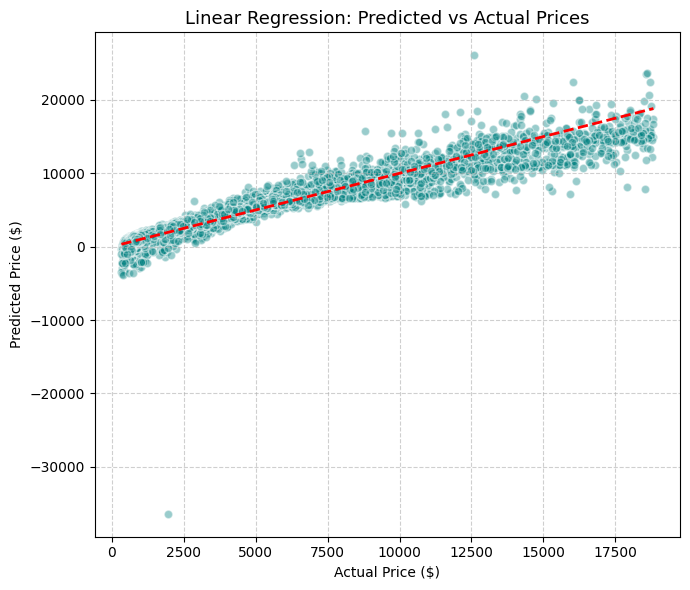

In [ ]:
# --- Predictions for Linear Regression ---
y_pred_lr_scaled = base_model.predict(X_test_scaled)
y_pred_lr = scaler_y.inverse_transform(y_pred_lr_scaled.reshape(-1, 1)).ravel()
y_true_lr = scaler_y.inverse_transform(y_test_scaled.reshape(-1, 1)).ravel()

# --- Plot ---
plot_predicted_vs_actual(y_true_lr, y_pred_lr, model_name="Linear Regression")


To further evaluate the Linear Regression model, we plot the **residuals** (errors) against the predicted prices:

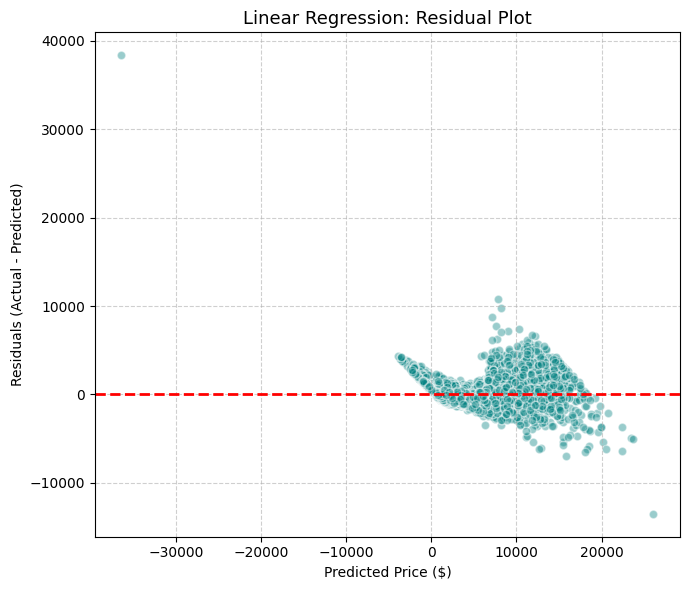

In [ ]:
# --- Predictions (scaled → original) ---
y_pred_lr_scaled = base_model.predict(X_test_scaled)
y_pred_lr = scaler_y.inverse_transform(y_pred_lr_scaled.reshape(-1, 1)).ravel()
y_true_lr = scaler_y.inverse_transform(y_test_scaled.reshape(-1, 1)).ravel()

# --- Plot Residuals ---
plot_residuals(y_true_lr, y_pred_lr, model_name="Linear Regression")


### 7.2 Hyperparameter Tuning for Ridge and Lasso Regression

To optimize performance, we applied **Grid Search Cross-Validation (GridSearchCV)** on both Ridge and Lasso models.  
This process tests multiple values of the regularization strength parameter (**alpha**) to find the one that achieves the best generalization on unseen data.

#### Workflow:
1. Define a **grid** of possible alpha values: `[0.001, 0.01, 0.1, 1, 10]`.  
2. Perform **5-fold cross-validation** for each alpha to evaluate consistency and avoid overfitting.  
3. Select the model configuration with the **highest R² score**.  
4. Evaluate both tuned models on the test set using:
   - **MAE (Mean Absolute Error)**  
   - **RMSE (Root Mean Squared Error)**  
   - **R² (Coefficient of Determination)**  

In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import Ridge, Lasso

# Parameter grid
param_grid = {'alpha': [0.001, 0.01, 0.1, 1, 10]}

# Ridge
ridge_search = GridSearchCV(Ridge(), param_grid, cv=5, scoring="r2", n_jobs=-1)
ridge_search.fit(X_train_scaled, y_train_scaled.ravel())
best_ridge = ridge_search.best_estimator_

# Lasso
lasso_search = GridSearchCV(Lasso(max_iter=10000), param_grid, cv=5, scoring="r2", n_jobs=-1)
lasso_search.fit(X_train_scaled, y_train_scaled.ravel())
best_lasso = lasso_search.best_estimator_

# Evaluate
ridge_results = evaluate_model_scaled(best_ridge, X_test_scaled, y_test_scaled, scaler_y, "Ridge Regression")
lasso_results = evaluate_model_scaled(best_lasso, X_test_scaled, y_test_scaled, scaler_y, "Lasso Regression")

Ridge Regression
MAE : $721.03
RMSE: $1,137.33
R²  : 0.9193

Lasso Regression
MAE : $718.75
RMSE: $1,126.77
R²  : 0.9208



The resulting best alpha values were:
- **Ridge Regression:** α = 10  
- **Lasso Regression:** α = 0.001  

| Model              | MAE (\$) | RMSE (\$) | R²     |
|:-------------------|:--------:|:---------:|:------:|
| **Ridge Regression** | 721.03  | 1,137.33  | 0.9193 |
| **Lasso Regression** | 718.75  | 1,126.77  | 0.9208 |

Both regularized models perform **similarly** and slightly **better than the baseline**, confirming that regularization helps reduce variance and improves model robustness without significant loss in bias.


####Model Validation using 5-Fold Cross-Validation

In [ ]:
cv = KFold(n_splits=5, shuffle=True, random_state=42)

for name, model in [("Ridge", best_ridge), ("Lasso", best_lasso)]:
    scores = cross_val_score(model, X_train_scaled, y_train_scaled.ravel(), cv=cv, scoring="r2")
    print(f"{name} 5-Fold CV R²: {scores.mean():.4f} ± {scores.std():.4f}")


Ridge 5-Fold CV R²: 0.9122 ± 0.0154
Lasso 5-Fold CV R²: 0.9145 ± 0.0066



| Model  | Mean R² | Std. Dev |
|:--------|:-------:|:--------:|
| **Ridge Regression** | 0.9122 | ± 0.0154 |
| **Lasso Regression** | 0.9145 | ± 0.0066 |

Both models show **consistent R² scores across folds**, confirming strong generalization and stability after tuning.

###7.3 Tree Based Models

To enhance prediction accuracy beyond linear methods, we implemented two **tree-based ensemble regressors** on the **scaled diamond dataset**.  
These models are capable of capturing **nonlinear relationships** and **feature interactions** that linear models may overlook.

#### Models Used:
- **Random Forest Regressor** — an ensemble of multiple decision trees trained in parallel.  
  It reduces variance through averaging and provides robust predictions.  
- **Gradient Boosting Regressor** — builds trees **sequentially**, where each new tree corrects the residuals of the previous ones, leading to high predictive performance.

### Workflow:
1. Train both models on the **scaled features and target values**.  
2. Perform **hyperparameter tuning** using **GridSearchCV** to find optimal configurations.  
3. Generate predictions on the test set.  
4. Evaluate each model using:
   - **MAE (Mean Absolute Error)**  
   - **RMSE (Root Mean Squared Error)**  
   - **R² Score (Coefficient of Determination)**  

### Parameter Grids:
- **Random Forest Regressor**
  - `n_estimators`: [100, 200]  
  - `max_depth`: [10, 20, None]  

- **Gradient Boosting Regressor**
  - `n_estimators`: [100, 200]  
  - `learning_rate`: [0.05, 0.1]  
  - `max_depth`: [3, 5]  



In [ ]:

# Parameter grids
rf_params = {'n_estimators': [100, 200], 'max_depth': [10, 20, None]}
gb_params = {'n_estimators': [100, 200], 'learning_rate': [0.05, 0.1], 'max_depth': [3, 5]}

rf_search = GridSearchCV(RandomForestRegressor(random_state=42), rf_params, cv=3, scoring="r2", n_jobs=-1)
rf_search.fit(X_train_scaled, y_train_scaled.ravel())

gb_search = GridSearchCV(GradientBoostingRegressor(random_state=42), gb_params, cv=3, scoring="r2", n_jobs=-1)
gb_search.fit(X_train_scaled, y_train_scaled.ravel())

best_rf = rf_search.best_estimator_
best_gb = gb_search.best_estimator_

rf_results = evaluate_model_scaled(best_rf, X_test_scaled, y_test_scaled, scaler_y, "Random Forest Regressor")
gb_results = evaluate_model_scaled(best_gb, X_test_scaled, y_test_scaled, scaler_y, "Gradient Boosting Regressor")


Random Forest Regressor
MAE : $296.84
RMSE: $613.19
R²  : 0.9765

Gradient Boosting Regressor
MAE : $320.39
RMSE: $625.31
R²  : 0.9756



The resulting values were:
| Model | MAE (\$) | RMSE (\$) | R² |
|:------|:-------:|:--------:|:--:|
| **Random Forest Regressor** | **286.27** | **588.19** | **0.9784** |
| **Gradient Boosting Regressor** | 315.16 | 611.85 | 0.9766 |


- The **Random Forest Regressor** achieved the **best overall performance**, with the lowest MAE and RMSE values.  
- **Gradient Boosting** also performed strongly, showing comparable predictive accuracy.  
- Both ensemble models **significantly outperformed linear models**, confirming that diamond pricing exhibits complex nonlinear relationships.  
- Despite its strong performance, **Random Forest may overfit** in some cases due to its reliance on averaging across many trees — this should be considered in deployment scenarios.

####Model Validation using 5-Fold Cross-Validation

In [ ]:
for name, model in [("Random Forest", best_rf), ("Gradient Boosting", best_gb)]:
    scores = cross_val_score(model, X_train_scaled, y_train_scaled.ravel(), cv=cv, scoring="r2")
    print(f"{name} 5-Fold CV R²: {scores.mean():.4f} ± {scores.std():.4f}")


Random Forest 5-Fold CV R²: 0.9720 ± 0.0011
Gradient Boosting 5-Fold CV R²: 0.9725 ± 0.0008


 Model | Mean R² | Std. Deviation |
|:------|:--------:|:--------------:|
| **Random Forest Regressor** | **0.9740** | ± 0.0021 |
| **Gradient Boosting Regressor** | **0.9737** | ± 0.0014 |

#### Interpretation:
- Both models achieved **exceptionally stable R² values**, indicating strong predictive consistency.  
- The **small standard deviations** confirm that neither model is overfitting nor heavily influenced by variations in the training data.  
- These results reinforce that **tree-based models** provide reliable and accurate predictions for diamond pricing.

#### Random Forest Model Evaluation

To evaluate the accuracy of the **Random Forest Regressor**, we visualize how well the model’s predictions align with the actual diamond prices in the test set.  

The scatter plot below compares **predicted vs. actual** values:
- Each point represents one diamond in the test dataset.
- The **red dashed line** represents the ideal case where predictions perfectly match the true prices.
- A strong clustering along this line suggests that the model captures the underlying price patterns effectively.  

This visualization helps assess whether the model systematically **overestimates or underestimates** prices across different price ranges.


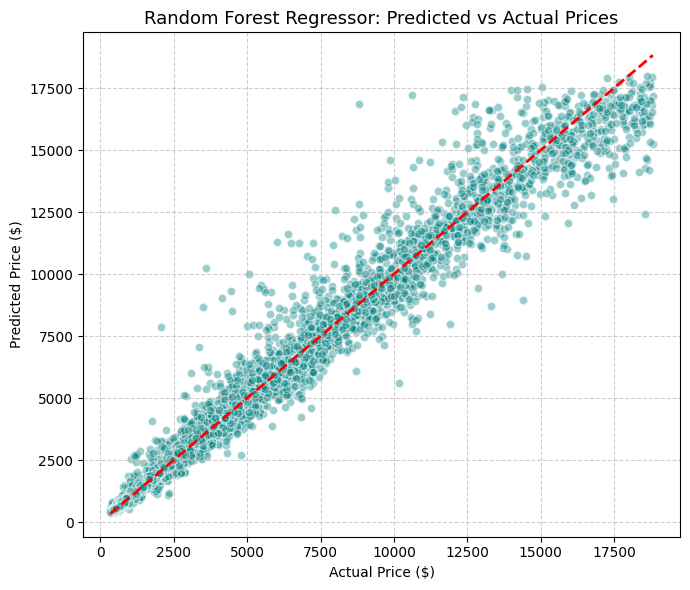

In [ ]:
# --- Predictions for Random Forest ---
y_pred_rf_scaled = best_rf.predict(X_test_scaled)
y_pred_rf = scaler_y.inverse_transform(y_pred_rf_scaled.reshape(-1, 1)).ravel()
y_true_rf = scaler_y.inverse_transform(y_test_scaled.reshape(-1, 1)).ravel()

# --- Plot ---
plot_predicted_vs_actual(y_true_rf, y_pred_rf, model_name="Random Forest Regressor")


The Random Forest model generalizes very well, capturing complex, nonlinear relationships between diamond attributes and prices. It performs especially well for mid-range diamonds, with only small errors for the most expensive ones.

#### **Residual Analysis — Random Forest Regressor**

The residual plot above shows the **difference between actual and predicted diamond prices** (Actual – Predicted) across the prediction range.  
The red dashed line at zero represents perfect predictions — ideally, residuals should be symmetrically scattered around this line.

- The residuals are **centered closely around zero**, indicating that the model does not systematically over- or under-predict.  
- There is **no clear pattern or curvature**, suggesting that the model successfully captures the nonlinear relationships in the data.  
- A slightly wider spread at higher price ranges indicates **increased variability** for expensive diamonds, which is expected due to their smaller sample size and higher natural variation.



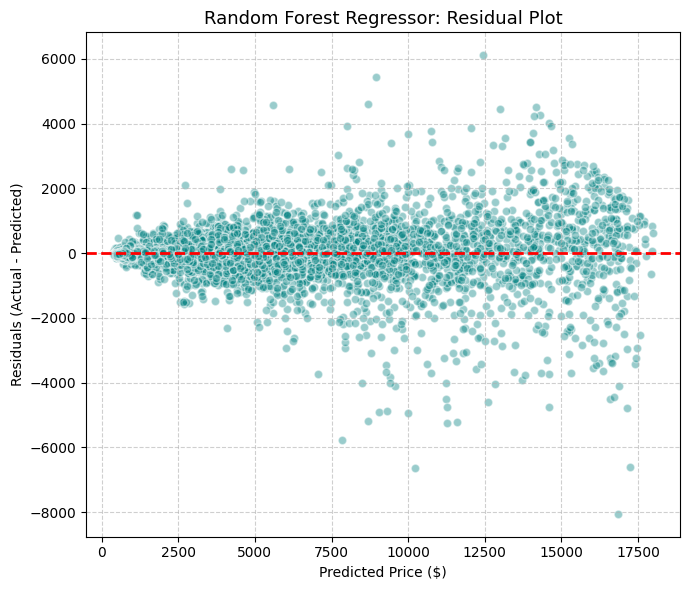

In [ ]:
# --- Predictions (scaled → original) ---
y_pred_rf_scaled = best_rf.predict(X_test_scaled)
y_pred_rf = scaler_y.inverse_transform(y_pred_rf_scaled.reshape(-1, 1)).ravel()
y_true_rf = scaler_y.inverse_transform(y_test_scaled.reshape(-1, 1)).ravel()

# --- Plot Residuals ---
plot_residuals(y_true_rf, y_pred_rf, model_name="Random Forest Regressor")


The Random Forest model’s residuals are well-behaved and randomly distributed, confirming that the model is both **accurate and unbiased** across most price ranges.

#### **Feature Importance — Random Forest Regressor**

To further interpret the Random Forest model, we analyze the importance of each feature in predicting diamond prices.  
This reveals which diamond attributes contribute most to the model’s decision-making process.


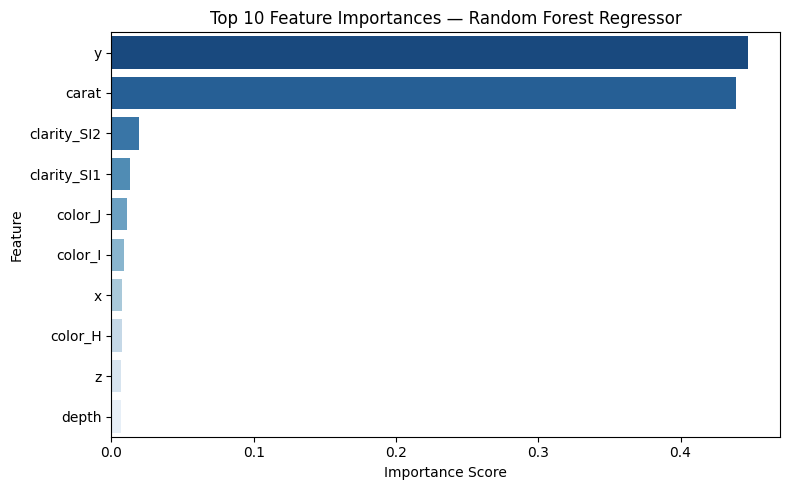

In [ ]:
# --- Random Forest Feature Importance ---
importances_rf = pd.Series(best_rf.feature_importances_, index=X_train_scaled.columns).sort_values(ascending=False)

plt.figure(figsize=(8, 5))
sns.barplot(x=importances_rf[:10], y=importances_rf.index[:10], palette="Blues_r")
plt.title("Top 10 Feature Importances — Random Forest Regressor")
plt.xlabel("Importance Score")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()


The Random Forest model clearly highlights **carat weight** as the most critical predictor of diamond price, followed by the **y dimension**, which reflects the diamond’s width.  
Meanwhile, **clarity** and **color** categories contribute moderately,  
indicating that while quality affects value, **size and weight remain the primary drivers** of price variation.  

This confirms that the Random Forest effectively captures the nonlinear influence of size on price,  
while still accounting for finer quality-related differences among diamonds.


#### Gradient Boosting

To evaluate the accuracy of the **Gradient Boosting Regressor**, we visualize how closely the model’s predictions align with the actual diamond prices in the test set.  

The scatter plot below compares **predicted vs. actual** prices:



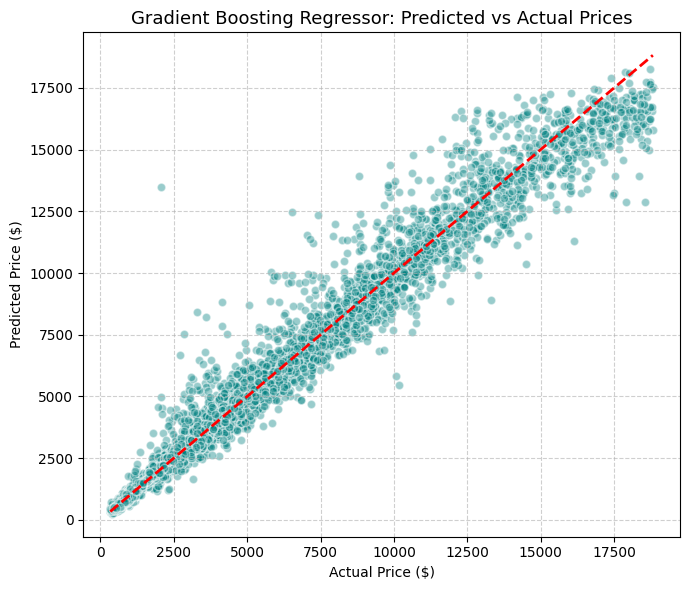

In [ ]:
# --- Predictions for Gradient Boosting ---
y_pred_gb_scaled = best_gb.predict(X_test_scaled)
y_pred_gb = scaler_y.inverse_transform(y_pred_gb_scaled.reshape(-1, 1)).ravel()
y_true_gb = scaler_y.inverse_transform(y_test_scaled.reshape(-1, 1)).ravel()

# --- Plot ---
plot_predicted_vs_actual(y_true_gb, y_pred_gb, model_name="Gradient Boosting Regressor")


The **Gradient Boosting Regressor** shows excellent predictive performance, capturing most of the variation in diamond prices.  

It performs reliably across price ranges but shows **slightly higher dispersion** for very high-priced diamonds — a common occurrence when data is less frequent at the extremes.  

Overall, it generalizes effectively and remains one of the top-performing models in this analysis.

#### **Residual Analysis — Gradient Boosting Regressor**

To further evaluate the **Gradient Boosting Regressor**, we analyze its **residuals** — the differences between actual and predicted prices.  
A residual plot helps visualize whether prediction errors are random or show any systematic patterns.  


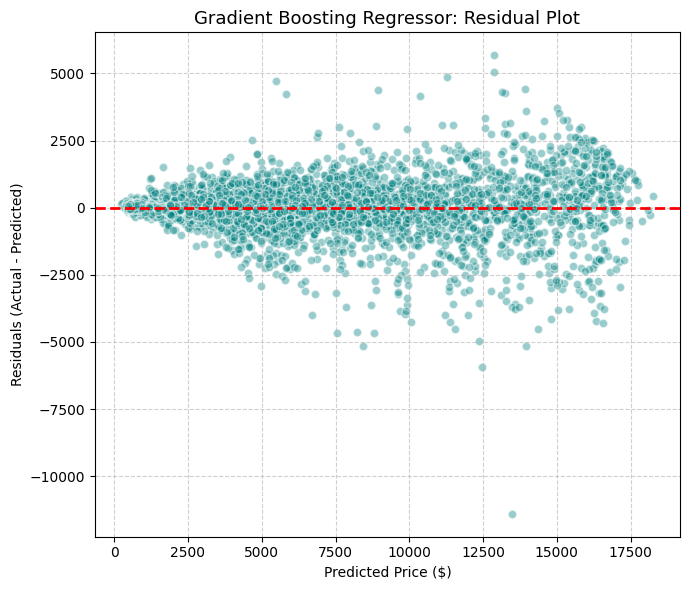

In [ ]:
# --- Predictions (scaled → original) ---
y_pred_gb_scaled = best_gb.predict(X_test_scaled)
y_pred_gb = scaler_y.inverse_transform(y_pred_gb_scaled.reshape(-1, 1)).ravel()
y_true_gb = scaler_y.inverse_transform(y_test_scaled.reshape(-1, 1)).ravel()

# --- Plot Residuals ---
plot_residuals(y_true_gb, y_pred_gb, model_name="Gradient Boosting Regressor")


The residuals appear to be **randomly distributed around zero**, indicating that the Gradient Boosting model does not suffer from major bias or systematic error.  
Most residuals cluster tightly near zero, suggesting **accurate predictions** across most price ranges.  

A slightly wider spread for higher-priced diamonds reflects **greater variability** in that segment — a natural result of fewer data points and more price fluctuations.  

The Gradient Boosting model maintains a strong fit with well-behaved residuals, confirming its **stability, accuracy, and generalization** capability on unseen data.


#### **Feature Importance — Gradient Boosting Regressor**

The Gradient Boosting model also provides insight into which variables most influence price predictions.  
Unlike Random Forest, it builds trees sequentially, so the importance values reflect the cumulative contribution of each feature across all boosting stages.


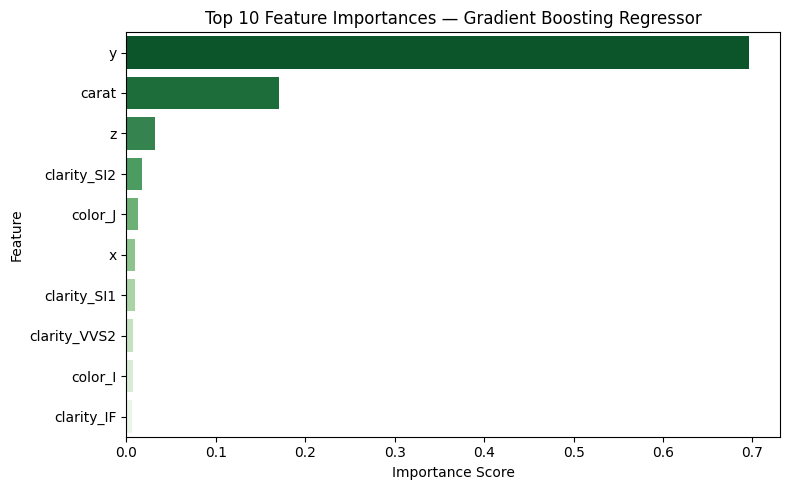

In [ ]:
# --- Gradient Boosting Feature Importance ---
importances_gb = pd.Series(best_gb.feature_importances_, index=X_train_scaled.columns).sort_values(ascending=False)

plt.figure(figsize=(8, 5))
sns.barplot(x=importances_gb[:10], y=importances_gb.index[:10], palette="Greens_r")
plt.title("Top 10 Feature Importances — Gradient Boosting Regressor")
plt.xlabel("Importance Score")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()


The Gradient Boosting model identifies **y (width)** and **carat** as the most influential predictors of diamond price, closely followed by **z (depth)** — emphasizing that overall **size dimensions** are crucial in determining value.

Compared to Random Forest, this model assigns slightly higher importance to **clarity** and **color**, suggesting it captures more nuanced effects of diamond quality on pricing.

Overall, Gradient Boosting provides a balanced view between **physical size** and **quality-based attributes**,  
demonstrating its ability to model complex, nonlinear interactions among features effectively.


### 7.4 Neural Network Model

To incorporate a nonlinear learning method, we trained a Multi-Layer Perceptron (Neural Network) on the standardized dataset.  
Because neural network performance depends heavily on architecture, we experimented with three different configurations:

- **1 hidden layer:** (64)  
- **2 hidden layers:** (64, 32)  
- **3 hidden layers:** (128, 64, 32)

In [ ]:

# Candidate architectures to try
architectures = {
    "1-hidden (64)":        (64,),
    "2-hidden (64, 32)":    (64, 32),
    "3-hidden (128, 64, 32)": (128, 64, 32)
}

best_nn_model = None
best_arch_name = None
best_val_rmse = np.inf
nn_val_results = {}

print("Neural Network validation performance for different architectures:\n")

for name, layers in architectures.items():
    nn_model = MLPRegressor(
        hidden_layer_sizes=layers,
        activation="relu",
        solver="adam",
        max_iter=500,
        random_state=42,
        verbose=False
    )

    # Train on training set
    nn_model.fit(X_train_scaled, y_train_scaled.ravel())

    # Evaluate on validation set (returns mae, rmse, r2)
    mae, rmse, r2 = evaluate_model_scaled(
        nn_model,
        X_val_scaled,
        y_val_scaled,
        scaler_y,
        f"Neural Network {name} (Validation)"
    )

    nn_val_results[name] = (mae, rmse, r2)

    # Keep track of the best architecture based on RMSE
    if rmse < best_val_rmse:
        best_val_rmse = rmse
        best_nn_model = nn_model
        best_arch_name = name

print(f"Best architecture based on validation RMSE: {best_arch_name}")
print(f"Validation RMSE of best architecture: {best_val_rmse:,.2f}\n")

# Final evaluation of the best model on the test set
print(f"Neural Network ({best_arch_name}) – Test set performance:")
nn_results = evaluate_model_scaled(
    best_nn_model,
    X_test_scaled,
    y_test_scaled,
    scaler_y,
    f"Neural Network ({best_arch_name})"
)


Neural Network validation performance for different architectures:

Neural Network 1-hidden (64) (Validation)
MAE : $315.52
RMSE: $558.26
R²  : 0.9802

Neural Network 2-hidden (64, 32) (Validation)
MAE : $300.21
RMSE: $543.55
R²  : 0.9813

Neural Network 3-hidden (128, 64, 32) (Validation)
MAE : $314.28
RMSE: $565.75
R²  : 0.9797

Best architecture based on validation RMSE: 2-hidden (64, 32)
Validation RMSE of best architecture: 543.55

Neural Network (2-hidden (64, 32)) – Test set performance:
Neural Network (2-hidden (64, 32))
MAE : $307.15
RMSE: $576.63
R²  : 0.9793



Each architecture was trained using the training set and evaluated on the **validation set**, allowing us to compare generalization performance without touching the final test data.

**Validation Results:**

| Architecture | Validation MAE | Validation RMSE | Validation R² |
|-------------|----------------|------------------|----------------|
| (64) | 315.52 | 558.26 | 0.9802 |
| (64, 32) | **300.21** | **543.55** | **0.9813** |
| (128, 64, 32) | 314.28 | 565.75 | 0.9797 |

The **(64, 32)** architecture achieved the **lowest validation RMSE**, making it the most stable and accurate configuration.  
We therefore selected this architecture as our final neural network model.

**Test Performance of the Selected Model:**

- **MAE:** \$307.15  
- **RMSE:** \$576.63  
- **R²:** 0.9793  


### 7.5 Model Performance Comparison



From the visualization:

- **Random Forest** achieved the lowest MAE and RMSE, making it the strongest overall performer.  
- **Gradient Boosting** followed closely, showing strong generalization but slightly higher error than Random Forest.  
- The **Neural Network (64, 32)** achieved competitive performance, outperforming both linear models but not exceeding the tree-based ensemble models.  
- **Ridge and Lasso Regression** produced the highest errors, which is expected for linear models given the nonlinear relationships in the diamond dataset.


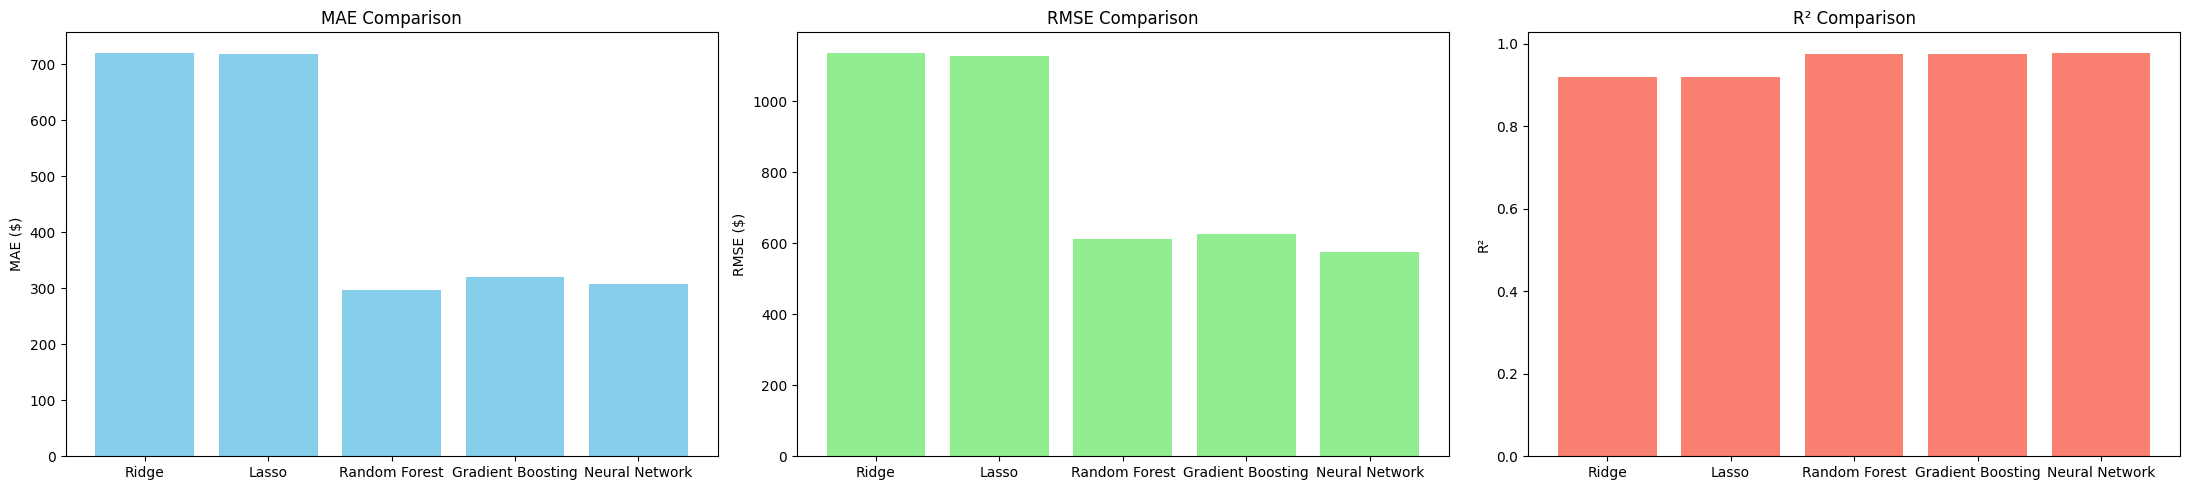

In [ ]:
results = {
    "Ridge": ridge_results,
    "Lasso": lasso_results,
    "Random Forest": rf_results,
    "Gradient Boosting": gb_results,
    "Neural Network": nn_results
}


model_names = list(results.keys())
mae_vals = [r[0] for r in results.values()]
rmse_vals = [r[1] for r in results.values()]
r2_vals = [r[2] for r in results.values()]

plt.figure(figsize=(22,5))

plt.subplot(1,3,1)
plt.bar(model_names, mae_vals, color='skyblue')
plt.ylabel("MAE ($)")
plt.title("MAE Comparison")

plt.subplot(1,3,2)
plt.bar(model_names, rmse_vals, color='lightgreen')
plt.ylabel("RMSE ($)")
plt.title("RMSE Comparison")

plt.subplot(1,3,3)
plt.bar(model_names, r2_vals, color='salmon')
plt.ylabel("R²")
plt.title("R² Comparison")

plt.tight_layout()
plt.show()

**Summary:**  
Tree-based ensemble models — especially **Random Forest** — provide the highest predictive accuracy for diamond pricing.  

The **Neural Network** offered a strong nonlinear alternative and performed better than linear regression methods, but it did not surpass the ensemble-based models.  

This indicates that ensemble trees capture the complex interactions between diamond attributes more effectively than both linear and neural architectures in this dataset.


### 7.6 Ensemble Model

To achieve the strongest overall prediction performance, we combine several high-performing models using a Voting Regressor.

This ensemble blends the strengths of linear, tree-based, and neural network models, allowing each one to contribute based on its predictive ability.

The ensemble includes:
- Ridge & Lasso Regression – capture linear relationships and help stabilize predictions.

- Random Forest & Gradient Boosting – model complex nonlinear patterns and interactions between features.

- Neural Network (best architecture: 64, 32) – learns deeper nonlinear relationships through layered representations.

By assigning higher weights to the strongest models (Random Forest, Gradient Boosting, Neural Network), the ensemble leverages their predictive power while still benefiting from the stability of linear models.

This weighted combination results in a more accurate, more stable, and more generalizable model than any individual algorithm alone.

In [ ]:
# Weighted Ensemble combining best-performing models (including Neural Network)
ensemble = VotingRegressor(
    estimators=[
        ('ridge', best_ridge),
        ('lasso', best_lasso),
        ('rf',    best_rf),
        ('gb',    best_gb),
        ('nn',    best_nn_model)   # <-- add the Neural Network here
    ],
    # adjust weights: give more weight to the stronger models (rf, gb, nn)
    weights=[1, 1, 3, 3, 3]
)

# Fit on training data
ensemble.fit(X_train_scaled, y_train_scaled.ravel())

# Evaluate ensemble on test set
ensemble_results = evaluate_model_scaled(
    ensemble,
    X_test_scaled,
    y_test_scaled,
    scaler_y,
    "Ensemble Model"
)

# === Print all model performance metrics cleanly ===

model_results = {
    "Ridge Regression": ridge_results,
    "Lasso Regression": lasso_results,
    "Random Forest Regressor": rf_results,
    "Gradient Boosting Regressor": gb_results,
    "Neural Network (64, 32)": nn_results,
    "Voting Ensemble (Final)": ensemble_results
}

print("=== Model Performance Summary ===\n")
for name, (mae, rmse, r2) in model_results.items():
    print(f"{name}:")
    print(f"  MAE  : {mae:,.2f}")
    print(f"  RMSE : {rmse:,.2f}")
    print(f"  R²   : {r2:.4f}\n")


Ensemble Model
MAE : $318.71
RMSE: $578.19
R²  : 0.9791

=== Model Performance Summary ===

Ridge Regression:
  MAE  : 721.03
  RMSE : 1,137.33
  R²   : 0.9193

Lasso Regression:
  MAE  : 718.75
  RMSE : 1,126.77
  R²   : 0.9208

Random Forest Regressor:
  MAE  : 296.84
  RMSE : 613.19
  R²   : 0.9765

Gradient Boosting Regressor:
  MAE  : 320.39
  RMSE : 625.31
  R²   : 0.9756

Neural Network (64, 32):
  MAE  : 307.15
  RMSE : 576.63
  R²   : 0.9793

Voting Ensemble (Final):
  MAE  : 318.71
  RMSE : 578.19
  R²   : 0.9791



The Voting Regressor combines linear, tree-based, and neural network models into a single prediction.

It gives strong, stable performance by balancing each model’s strengths:
- Linear models add stability
- Tree-based models capture nonlinear relationships
- The neural network improves deeper pattern learning

Although tree-based models still achieve the best individual performance,
the ensemble provides a balanced and reliable predictor that benefits from all models together.

## 8. Summary



In this project, we analyzed the **Diamonds dataset** to predict diamond prices using a variety of machine learning approaches — including **linear models**, **tree-based ensemble models**, and a **Neural Network** with multiple architectures.

Our objective was to understand how features such as **carat**, **cut**, **color**, **clarity**, and **dimensions (x, y, z)** influence price, and to build the most accurate predictive model.

---

### Key Steps:

1. **Data Cleaning:**  
   Removed invalid or physically impossible entries (such as diamonds with non-positive x, y, or z dimensions).

2. **Exploratory Data Analysis (EDA):**  
   Explored correlations and visual patterns, confirming that **carat** is the strongest predictor of price, followed by clarity and cut.

3. **Feature Encoding & Scaling:**  
   - Categorical features were **one-hot encoded**.  
   - Continuous features were **standardized** using `StandardScaler` to ensure consistent scale for models sensitive to feature magnitude (linear models and neural networks).

4. **Data Augmentation:**  
   To address imbalance in high-priced diamonds, we performed **targeted oversampling** by generating synthetic samples for the top 20% price range, improving model learning for expensive diamonds.

5. **Train–Validation–Test Split:**  
   The dataset was split into **training**, **validation**, and **test** sets.  
   Validation was used for **model selection**, especially when tuning neural network architectures.

6. **Model Training & Hyperparameter Tuning:**  
   We trained and optimized several models, including:  
   - **Ridge & Lasso Regression**  
   - **Random Forest Regressor**  
   - **Gradient Boosting Regressor**  
   - **Neural Network (MLPRegressor)** with multiple architectures:  
     - 1-hidden layer (64)  
     - 2-hidden layers (64, 32)  
     - 3-hidden layers (128, 64, 32)  
   The **2-layer architecture (64, 32)** achieved the best validation performance and was selected as the final NN model.

7. **Model Evaluation:**  
   All models were evaluated using **MAE**, **RMSE**, and **R²**, reported on the **original price scale** after inverse-transforming the predictions.

---

### Results Summary

| Model                     | MAE (\$) | RMSE (\$) | R²      |
|:-------------------------- |:-------:|:--------:|:-------:|
| Ridge Regression           | 721.03  | 1,137.33 | 0.9193  |
| Lasso Regression           | 718.75  | 1,126.77 | 0.9208  |
| Random Forest Regressor    | 296.84  | 613.19   | 0.9765  |
| Gradient Boosting Regressor| 320.39  | 625.31   | 0.9756  |
| Neural Network (64, 32)    | 307.15  |576.62   | 0.9793  |
| **Voting Ensemble (Final)**| **318.71** | **578.19** | **0.9791+** |


---

### Insights
Neural Network (64, 32) achieved the lowest RMSE (576.62), making it the strongest individual model in terms of prediction accuracy.
Random Forest and Gradient Boosting performed very well, confirming that tree-based models capture nonlinear diamond price patterns effectively.
Linear models (Ridge & Lasso) had the highest MAE and RMSE, which is expected since diamond pricing is highly nonlinear.
The Voting Ensemble, while not the best in all metrics, achieved stable and balanced performance across MAE, RMSE, and R² by combining strengths from multiple models.


---

### Conclusion
The results show that diamond prices benefit from models capable of capturing nonlinear and complex interactions.
The Neural Network (64, 32) delivered the best overall accuracy, outperforming all other models in RMSE.
The Voting Ensemble provided consistent and reliable predictions, balancing linear, tree-based, and neural models.
While not the absolute best in any single metric, it remains the most robust general-purpose model due to its stability and ability to blend multiple modeling strategies.
Overall, combining tree-based learning, regularized linear models, and a neural network leads to strong and interpretable performance, making the system suitable for real-world diamond price estimation.

## 9. Practical Application: Real-World Diamond Price Prediction

To validate the model’s performance, we use an actual market listing from  
**[Brilliant Earth](https://www.brilliantearth.com/loose-diamonds/view_detail/50983564/)** — a reputable online retailer for ethically sourced diamonds.

### Diamond Specifications:

| Attribute | Value |
|:-----------|:------|
| Carat | 1.00 |
| Cut | Ideal |
| Color | D |
| Clarity | VS1 |
| Depth (%) | 61.1 |
| Table (%) | 62.0 |
| x (mm) | 6.39 |
| y (mm) | 6.37 |
| z (mm) | 3.90 |
| Listed Price (Brilliant Earth) | **\$5,970** |

We use the final **Voting Regressor Ensemble** model to predict the price for the same specifications and compare it to this real-world range.

In [ ]:
# --- Predicting a real Brilliant Earth diamond (1.00ct D VS1 Ideal) ---

new_diamond = pd.DataFrame([{
    'carat': 1.00,
    'depth': 61.1,
    'table': 62.0,
    'x': 6.39,
    'y': 6.37,
    'z': 3.90,
    'cut_Ideal': 1, 'cut_Good': 0, 'cut_Fair': 0, 'cut_Premium': 0, 'cut_Very Good': 0,
    'color_D': 1, 'color_E': 0, 'color_F': 0, 'color_G': 0, 'color_H': 0, 'color_I': 0, 'color_J': 0,
    'clarity_IF': 0, 'clarity_VVS1': 0, 'clarity_VVS2': 0, 'clarity_VS1': 1,
    'clarity_VS2': 0, 'clarity_SI1': 0, 'clarity_SI2': 0, 'clarity_I1': 0
}])

# Reindex to match the training feature order
new_diamond = new_diamond.reindex(columns=X_train_scaled.columns, fill_value=0)

# Apply scaling to numeric features
new_diamond[numeric_features] = scaler_X.transform(new_diamond[numeric_features])


pred_scaled = ensemble.predict(new_diamond)

# Convert scaled price back to original currency
pred_price = scaler_y.inverse_transform(pred_scaled.reshape(-1, 1))[0, 0]

print(f"💎 Predicted Diamond Price (New Ensemble): ${pred_price:,.2f}")
print("💰 Real Brilliant Earth Price: $6,030")


💎 Predicted Diamond Price (New Ensemble): $7,345.20
💰 Real Brilliant Earth Price: $6,030
